In [1]:
# Load your clean file and import chart libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('Online_Sales_Clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

sns.set_theme(style="whitegrid")
print("Data loaded! Shape:", df.shape)
df.head()

Data loaded! Shape: (240, 12)


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Month,Year,Month_Name
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,1,2024,January
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,1,2024,January
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,1,2024,January
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,1,2024,January
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,1,2024,January


          Region  Total_Revenue  Total_Orders
0  North America       36844.34            80
1           Asia       22455.45            80
2         Europe       21268.06            80


/tmp/ipykernel_545/2056293950.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Total_Revenue',


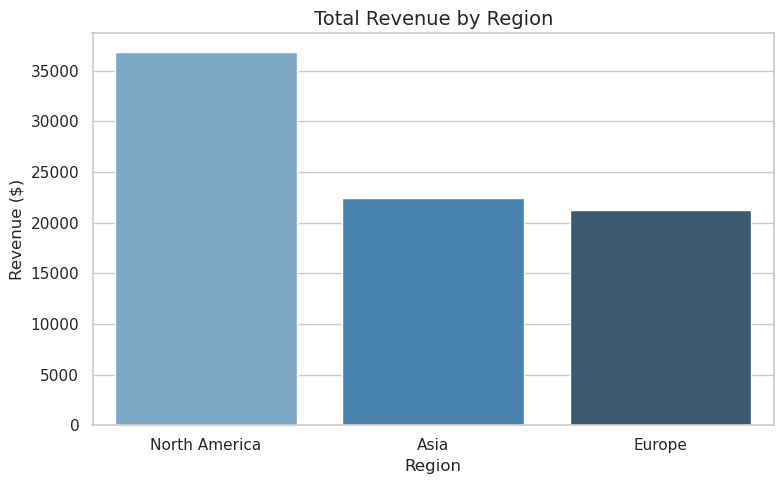

In [2]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)

region_sales = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM("Total Revenue"), 2) AS Total_Revenue,
           COUNT(*) AS Total_Orders
    FROM sales
    GROUP BY Region
    ORDER BY Total_Revenue DESC
""", conn)

print(region_sales)

# Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='Region', y='Total_Revenue',
            palette='Blues_d')
plt.title('Total Revenue by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart_region_revenue.png')
plt.show()

  Product Category  Total_Revenue  Total_Units
0      Electronics       34982.41           66
1  Home Appliances       18646.16           59
2           Sports       14326.52           88
3         Clothing        8128.93          145
4  Beauty Products        2621.90           46
5            Books        1861.93          114


/tmp/ipykernel_545/3642236126.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Total_Revenue',


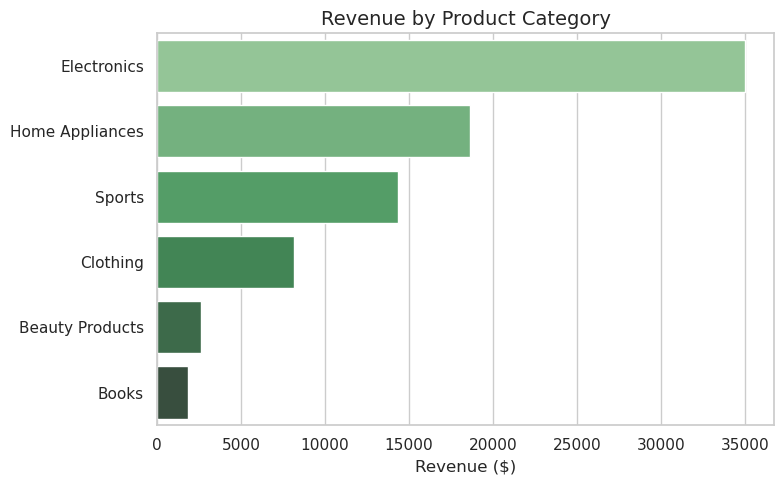

In [3]:
# SQL: Which category makes the most money?
category_sales = pd.read_sql_query("""
    SELECT "Product Category",
           ROUND(SUM("Total Revenue"), 2) AS Total_Revenue,
           SUM("Units Sold") AS Total_Units
    FROM sales
    GROUP BY "Product Category"
    ORDER BY Total_Revenue DESC
""", conn)

print(category_sales)

# Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Total_Revenue',
            y='Product Category', palette='Greens_d')
plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart_category_revenue.png')
plt.show()

   Month Month_Name  Total_Revenue  Orders
0      1    January       14548.32      31
1      2   February       10803.37      29
2      3      March       12849.24      31
3      4      April       12451.69      30
4      5        May        8455.49      31
5      6       June        7384.55      30
6      7       July        6797.08      31
7      8     August        7278.11      27


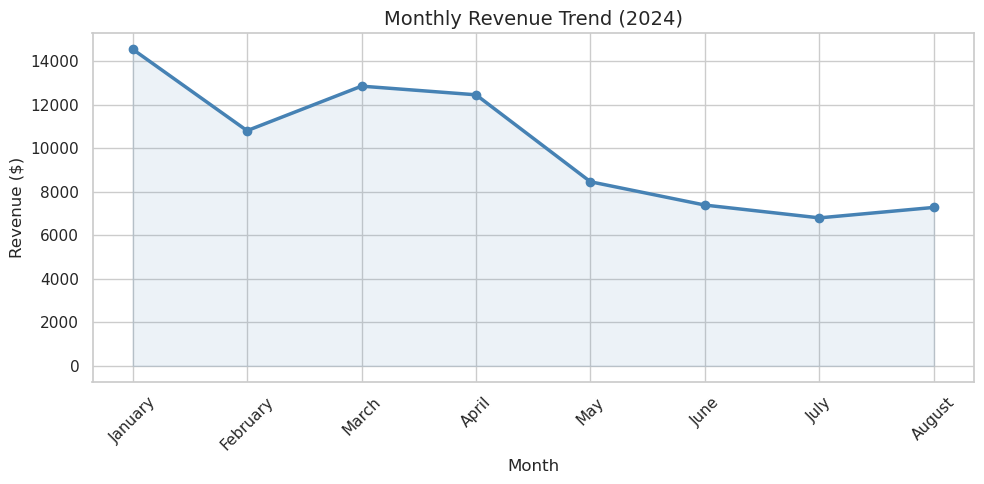

In [4]:
# SQL: How did revenue change month by month?
monthly = pd.read_sql_query("""
    SELECT Month, Month_Name,
           ROUND(SUM("Total Revenue"), 2) AS Total_Revenue,
           COUNT(*) AS Orders
    FROM sales
    GROUP BY Month, Month_Name
    ORDER BY Month ASC
""", conn)

print(monthly)

# Chart
plt.figure(figsize=(10, 5))
plt.plot(monthly['Month_Name'], monthly['Total_Revenue'],
         marker='o', linewidth=2.5, color='steelblue')
plt.fill_between(monthly['Month_Name'],
                 monthly['Total_Revenue'], alpha=0.1, color='steelblue')
plt.title('Monthly Revenue Trend (2024)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_monthly_trend.png')
plt.show()

  Payment Method  Total_Orders  Total_Revenue
0    Credit Card           120       51170.86
1         PayPal            80       21268.06
2     Debit Card            40        8128.93


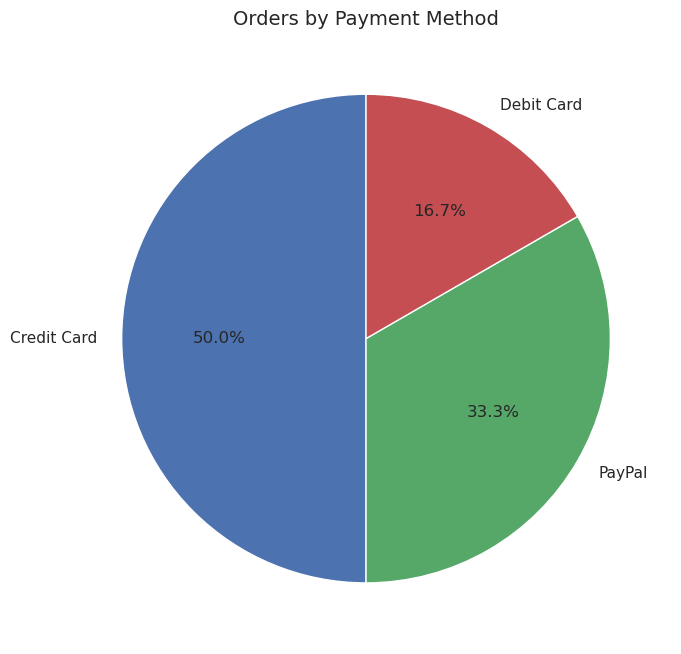

In [5]:
# SQL: How do customers prefer to pay?
payment = pd.read_sql_query("""
    SELECT "Payment Method",
           COUNT(*) AS Total_Orders,
           ROUND(SUM("Total Revenue"), 2) AS Total_Revenue
    FROM sales
    GROUP BY "Payment Method"
    ORDER BY Total_Orders DESC
""", conn)

print(payment)

# Chart
plt.figure(figsize=(7, 7))
plt.pie(payment['Total_Orders'],
        labels=payment['Payment Method'],
        autopct='%1.1f%%',
        colors=['#4C72B0','#55A868','#C44E52'],
        startangle=90)
plt.title('Orders by Payment Method', fontsize=14)
plt.tight_layout()
plt.savefig('chart_payment_method.png')
plt.show()

                        Product Name  Total_Revenue  Units_Sold
0                Canon EOS R5 Camera        3899.99           1
1                         LG OLED TV        2599.98           2
2                MacBook Pro 16-inch        2499.99           1
3          Apple MacBook Pro 16-inch        2399.00           1
4                      iPhone 14 Pro        1999.98           2
5                       Peloton Bike        1895.00           1
6             HP Spectre x360 Laptop        1599.99           1
7                         Roomba i7+        1599.98           2
8              Garmin Forerunner 945        1599.97           3
9  Samsung Odyssey G9 Gaming Monitor        1499.99           1


/tmp/ipykernel_545/1149302416.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Total_Revenue',


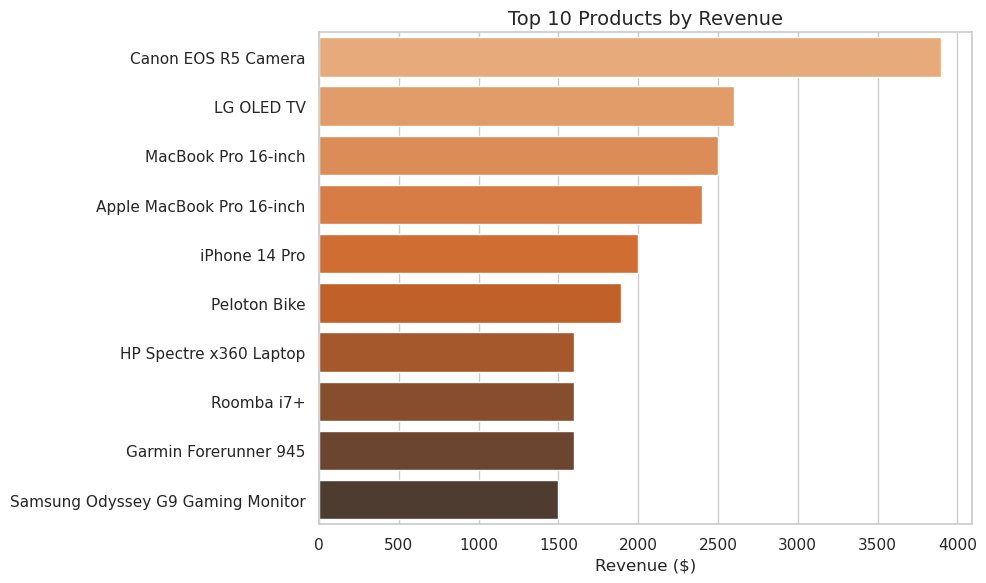

In [6]:
# SQL: What are the top 10 best selling products?
top_products = pd.read_sql_query("""
    SELECT "Product Name",
           ROUND(SUM("Total Revenue"), 2) AS Total_Revenue,
           SUM("Units Sold") AS Units_Sold
    FROM sales
    GROUP BY "Product Name"
    ORDER BY Total_Revenue DESC
    LIMIT 10
""", conn)

print(top_products)

# Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Total_Revenue',
            y='Product Name', palette='Oranges_d')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart_top_products.png')
plt.show()

In [7]:
# Print the key business numbers (KPIs)
total_revenue = df['Total Revenue'].sum()
total_orders  = len(df)
avg_order     = df['Total Revenue'].mean()
top_category  = df.groupby('Product Category')['Total Revenue'].sum().idxmax()
top_region    = df.groupby('Region')['Total Revenue'].sum().idxmax()

print("=" * 40)
print("       BUSINESS KPI SUMMARY")
print("=" * 40)
print(f"Total Revenue    : ${total_revenue:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Avg Order Value  : ${avg_order:,.2f}")
print(f"Top Category     : {top_category}")
print(f"Top Region       : {top_region}")
print("=" * 40)

       BUSINESS KPI SUMMARY
Total Revenue    : $80,567.85
Total Orders     : 240
Avg Order Value  : $335.70
Top Category     : Electronics
Top Region       : North America
